In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

In [4]:
transactions = pd.read_csv("../data/raw/Transactions.csv")
products = pd.read_csv("../data/raw/Products.csv")

print("Transactions shape:", transactions.shape)
print("Products shape:", products.shape)

Transactions shape: (53820, 11)
Products shape: (96, 6)


In [5]:
print("TRANSACTIONS COLUMNS")
print(transactions.columns.tolist())

print("\nPRODUCTS COLUMNS")
print(products.columns.tolist())

TRANSACTIONS COLUMNS
['Outlet', 'Date', 'Time', 'NetSales', 'Tax', 'TotalAmount', 'ReceiptNumber', 'Items', 'TotalItem', 'PaymentMethod', 'UseLoyaltyCard']

PRODUCTS COLUMNS
['ProductId', 'ProductName', 'Variant', 'Category', 'Price', 'Description']


In [6]:
transactions.head()

,Outlet,Date,Time,NetSales,Tax,TotalAmount,ReceiptNumber,Items,TotalItem,PaymentMethod,UseLoyaltyCard
0,SHOP001,2025-01-02,07:01:05,20720.721,2279.279,23000,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0
1,SHOP001,2025-01-02,07:04:11,18018.018,1981.982,20000,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0
2,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0
3,SHOP002,2025-01-02,07:14:25,36036.036,3963.964,40000,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0
4,SHOP002,2025-01-02,07:23:05,36036.036,3963.964,40000,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0


In [7]:
products.head()

,ProductId,ProductName,Variant,Category,Price,Description
0,1,Add on Aren,-,Add on,0,"Tambahan sirup gula aren murni, memberikan ras..."
1,2,Add on Simple Syrup,-,Add on,0,Tambahan sirup gula sederhana (air dan gula) s...
2,3,Air Mineral,-,Other,5000,Air minum murni dalam kemasan
3,4,Americano,Hot Houseblend,Coffee,20000,Minuman kopi hitam yang dibuat dengan menambah...
4,5,Americano,Ice Houesblend,Coffee,20000,Minuman kopi hitam yang dibuat dengan menambah...


In [8]:
print("TRANSACTIONS INFO")
transactions.info()

print("\nPRODUCTS INFO")
products.info()

TRANSACTIONS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53820 entries, 0 to 53819
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Outlet          53820 non-null  object 
 1   Date            53820 non-null  object 
 2   Time            53820 non-null  object 
 3   NetSales        53820 non-null  float64
 4   Tax             53820 non-null  float64
 5   TotalAmount     53820 non-null  int64  
 6   ReceiptNumber   53820 non-null  object 
 7   Items           53820 non-null  object 
 8   TotalItem       53820 non-null  int64  
 9   PaymentMethod   53820 non-null  object 
 10  UseLoyaltyCard  53820 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 4.5+ MB

PRODUCTS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ProductId    96 non-nu

In [9]:
print("=== DATE RANGE ===")
print("Start:", transactions["Date"].min())
print("End:", transactions["Date"].max())

print("\n=== OUTLETS ===")
print(transactions["Outlet"].unique())
print("Total outlet:", transactions["Outlet"].nunique())

print("\n=== TOTAL ITEM DISTRIBUTION ===")
print(transactions["TotalItem"].value_counts().sort_index())

=== DATE RANGE ===
Start: 2025-01-02
End: 2025-09-30

=== OUTLETS ===
['SHOP001' 'SHOP002' 'SHOP003']
Total outlet: 3

=== TOTAL ITEM DISTRIBUTION ===
TotalItem
1    45667
2     8153
Name: count, dtype: int64


In [10]:
print("=== SAMPLE ITEMS ===")

for item in transactions["Items"].sample(20, random_state=42):
    print(item)

=== SAMPLE ITEMS ===
Jus Semangka
Friendly Coffee (Gedhe)
Lemons
Matcha Latte (Hot)
Vanilla Latte (Gedhe)
Americano (Hot Houseblend)
Chamomile
Matcha Latte (Ice)
Berry Cake
Candy Latte
Pisang Coklat
Not Tiramisu Latte (Gedhe)
Friendly Coffee (Hot)
Creamy Chocolate Cake
Green Thai Tea
Apple Pie Latte (Gedhe)
Air Mineral
Biru
Burnt Sugar
Susu Oat, Thai Tea (Gedhe)


In [11]:
print("Duplicate rows:", transactions.duplicated().sum())

print(
    "Duplicate ReceiptNumber:",
    transactions["ReceiptNumber"].duplicated().sum()
)

Duplicate rows: 0
Duplicate ReceiptNumber: 0


In [12]:
# Hitung jumlah item berdasarkan pemisah koma
transactions["ParsedItemCount"] = (
    transactions["Items"]
    .str.split(",")
    .str.len()
)

# Bandingkan dengan TotalItem
count_check = (
    transactions["ParsedItemCount"]
    == transactions["TotalItem"]
)

print("Jumlah transaksi:", len(transactions))
print("Jumlah cocok:", count_check.sum())
print("Jumlah tidak cocok:", (~count_check).sum())
print("Persentase cocok:", count_check.mean() * 100, "%")

Jumlah transaksi: 53820
Jumlah cocok: 53820
Jumlah tidak cocok: 0
Persentase cocok: 100.0 %


In [13]:
transactions.loc[
    transactions["ParsedItemCount"] != transactions["TotalItem"],
    ["ReceiptNumber", "Items", "TotalItem", "ParsedItemCount"]
].head(20)

,ReceiptNumber,Items,TotalItem,ParsedItemCount


In [14]:
products["ItemName"] = products.apply(
    lambda row: (
        row["ProductName"]
        if row["Variant"] == "-"
        else f'{row["ProductName"]} ({row["Variant"]})'
    ),
    axis=1
)

products[["ProductName", "Variant", "ItemName"]].head(20)

,ProductName,Variant,ItemName
0,Add on Aren,-,Add on Aren
1,Add on Simple Syrup,-,Add on Simple Syrup
2,Air Mineral,-,Air Mineral
3,Americano,Hot Houseblend,Americano (Hot Houseblend)
4,Americano,Ice Houesblend,Americano (Ice Houesblend)
5,Americano,Hot Arabica,Americano (Hot Arabica)
6,Americano,Ice Arabica,Americano (Ice Arabica)
7,Apple Pie Latte,-,Apple Pie Latte
8,Apple Pie Latte (Gedhe),-,Apple Pie Latte (Gedhe)
9,BLACK,-,BLACK


In [15]:
transaction_items = (
    transactions["Items"]
    .str.split(",")
    .explode()
    .str.strip()
)

print("Jumlah item setelah explode:", len(transaction_items))
print("Jumlah nama item unik:", transaction_items.nunique())

transaction_items.unique()[:30]

Jumlah item setelah explode: 61973
Jumlah nama item unik: 94


array(['Basic Latte (Ice Arabica)', 'BLACK (Houseblend)',
       'Friendly Coffee (Hot)', 'Shakencano', 'BLACK (Arabica)',
       'Americano (Hot Arabica)', 'WHITE (Arabica)', 'Susu Oat',
       'Americano (Hot Houseblend)', 'Banana Bread (Chocolate)',
       'Not Tiramisu Latte (Gedhe)', 'Espresso Arabica (On The Rock)',
       'Jasmine (Hot)', 'Jus Semangka', 'Sitrus Cafe',
       'Hazelnut Latte (Gedhe)', 'Gula Gula', 'Happy Moca (Ice)',
       'Friendly Coffee (Ice)', 'Vanilla Latte (Gedhe)', 'Sunset',
       'Not Tiramisu Latte', 'Green Thai Tea',
       'Cappuccino (Ice Houseblend)', 'Espresso Arabica (Basic Espresso)',
       'Burnt Sugar', 'Espresso Houseblend (On The Rock)',
       'Basic Latte (Hot Arabica)', 'Friendly Coffee (Hot double shot)',
       'Chocolate (Ice)'], dtype=object)

In [16]:
product_names = set(products["ItemName"])

unmatched_items = sorted(
    set(transaction_items) - product_names
)

print("Jumlah unmatched item:", len(unmatched_items))

unmatched_items[:50]

Jumlah unmatched item: 0


[]

In [17]:
# Buat copy agar data asli tidak berubah
items_df = transactions.copy()

# Pecah Items berdasarkan koma
items_df["ItemName"] = items_df["Items"].str.split(",")

# Ubah setiap item menjadi satu baris
items_df = items_df.explode("ItemName")

# Bersihkan spasi
items_df["ItemName"] = items_df["ItemName"].str.strip()

print("Transactions awal :", len(transactions))
print("Setelah explode   :", len(items_df))

items_df.head(10)

Transactions awal : 53820
Setelah explode   : 61973


,Outlet,Date,Time,NetSales,Tax,TotalAmount,ReceiptNumber,Items,TotalItem,PaymentMethod,UseLoyaltyCard,ParsedItemCount,ItemName
0,SHOP001,2025-01-02,07:01:05,20720.721,2279.279,23000,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0,1,Basic Latte (Ice Arabica)
1,SHOP001,2025-01-02,07:04:11,18018.018,1981.982,20000,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0,1,BLACK (Houseblend)
2,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0,2,Friendly Coffee (Hot)
2,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0,2,Shakencano
3,SHOP002,2025-01-02,07:14:25,36036.036,3963.964,40000,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0,2,BLACK (Arabica)
3,SHOP002,2025-01-02,07:14:25,36036.036,3963.964,40000,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0,2,Americano (Hot Arabica)
4,SHOP002,2025-01-02,07:23:05,36036.036,3963.964,40000,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0,2,WHITE (Arabica)
4,SHOP002,2025-01-02,07:23:05,36036.036,3963.964,40000,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0,2,Susu Oat
5,SHOP001,2025-01-02,07:40:48,18018.018,1981.982,20000,SHOP001JAN2500003,Americano (Hot Houseblend),1,BCA,0,1,Americano (Hot Houseblend)
6,SHOP002,2025-01-02,07:42:40,10810.811,1189.189,12000,SHOP002JAN2500004,Banana Bread (Chocolate),1,Cash,0,1,Banana Bread (Chocolate)


In [18]:
sample_receipt = transactions.loc[
    transactions["TotalItem"] == 2,
    "ReceiptNumber"
].iloc[0]

print("Receipt:", sample_receipt)

items_df.loc[
    items_df["ReceiptNumber"] == sample_receipt,
    [
        "Date",
        "Outlet",
        "ReceiptNumber",
        "ItemName",
        "TotalItem"
    ]
]

Receipt: SHOP002JAN2500001


,Date,Outlet,ReceiptNumber,ItemName,TotalItem
2,2025-01-02,SHOP002,SHOP002JAN2500001,Friendly Coffee (Hot),2
2,2025-01-02,SHOP002,SHOP002JAN2500001,Shakencano,2


In [19]:
print("Jumlah baris:", len(items_df))
print("Missing ItemName:", items_df["ItemName"].isna().sum())
print("Item kosong:", (items_df["ItemName"] == "").sum())
print("Receipt unik:", items_df["ReceiptNumber"].nunique())

Jumlah baris: 61973
Missing ItemName: 0
Item kosong: 0
Receipt unik: 53820


In [20]:
items_merged = items_df.merge(
    products[
        [
            "ProductId",
            "ProductName",
            "Variant",
            "Category",
            "Price",
            "ItemName"
        ]
    ],
    on="ItemName",
    how="left",
    validate="many_to_one"
)

print("Sebelum merge :", len(items_df))
print("Setelah merge :", len(items_merged))

items_merged.head()

Sebelum merge : 61973
Setelah merge : 61973


,Outlet,Date,Time,NetSales,Tax,TotalAmount,ReceiptNumber,Items,TotalItem,PaymentMethod,UseLoyaltyCard,ParsedItemCount,ItemName,ProductId,ProductName,Variant,Category,Price
0,SHOP001,2025-01-02,07:01:05,20720.721,2279.279,23000,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0,1,Basic Latte (Ice Arabica),18,Basic Latte,Ice Arabica,Coffee,23000
1,SHOP001,2025-01-02,07:04:11,18018.018,1981.982,20000,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0,1,BLACK (Houseblend),11,BLACK,Houseblend,Menu Gedhe,20000
2,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0,2,Friendly Coffee (Hot),49,Friendly Coffee,Hot,Coffee,23000
3,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0,2,Shakencano,79,Shakencano,-,Coffee,21000
4,SHOP002,2025-01-02,07:14:25,36036.036,3963.964,40000,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0,2,BLACK (Arabica),12,BLACK,Arabica,Menu Gedhe,20000


In [21]:
print("=== MISSING SETELAH MERGE ===")

print(
    items_merged[
        ["ProductId", "ProductName", "Variant", "Category", "Price"]
    ]
    .isna()
    .sum()
)

=== MISSING SETELAH MERGE ===
ProductId      0
ProductName    0
Variant        0
Category       0
Price          0
dtype: int64


In [22]:
items_merged["Quantity"] = 1

In [23]:
items_merged[
    [
        "Date",
        "Outlet",
        "ProductId",
        "ProductName",
        "Variant",
        "Category",
        "Quantity"
    ]
].head(10)

,Date,Outlet,ProductId,ProductName,Variant,Category,Quantity
0,2025-01-02,SHOP001,18,Basic Latte,Ice Arabica,Coffee,1
1,2025-01-02,SHOP001,11,BLACK,Houseblend,Menu Gedhe,1
2,2025-01-02,SHOP002,49,Friendly Coffee,Hot,Coffee,1
3,2025-01-02,SHOP002,79,Shakencano,-,Coffee,1
4,2025-01-02,SHOP002,12,BLACK,Arabica,Menu Gedhe,1
5,2025-01-02,SHOP002,6,Americano,Hot Arabica,Coffee,1
6,2025-01-02,SHOP002,92,WHITE,Arabica,Menu Gedhe,1
7,2025-01-02,SHOP002,84,Susu Oat,-,Add on,1
8,2025-01-02,SHOP001,4,Americano,Hot Houseblend,Coffee,1
9,2025-01-02,SHOP002,13,Banana Bread,Chocolate,Snacks,1


In [24]:
items_merged["Date"] = pd.to_datetime(items_merged["Date"])

print(items_merged["Date"].dtype)

datetime64[ns]


In [25]:
daily_sales = (
    items_merged
    .groupby(
        [
            "Date",
            "Outlet",
            "ProductId",
            "ProductName",
            "Variant",
            "Category"
        ],
        as_index=False
    )
    .agg(
        QuantitySold=("Quantity", "sum")
    )
)

In [26]:
daily_sales.head(20)

,Date,Outlet,ProductId,ProductName,Variant,Category,QuantitySold
0,2025-01-02,SHOP001,3,Air Mineral,-,Other,2
1,2025-01-02,SHOP001,4,Americano,Hot Houseblend,Coffee,1
2,2025-01-02,SHOP001,5,Americano,Ice Houesblend,Coffee,1
3,2025-01-02,SHOP001,7,Americano,Ice Arabica,Coffee,2
4,2025-01-02,SHOP001,9,Apple Pie Latte (Gedhe),-,Menu Gedhe,1
5,2025-01-02,SHOP001,10,BLACK,-,Menu Gedhe,1
6,2025-01-02,SHOP001,11,BLACK,Houseblend,Menu Gedhe,1
7,2025-01-02,SHOP001,12,BLACK,Arabica,Menu Gedhe,2
8,2025-01-02,SHOP001,13,Banana Bread,Chocolate,Snacks,1
9,2025-01-02,SHOP001,15,Basic Latte,Hot Arabica,Coffee,1


In [27]:
print("Jumlah baris daily sales:", len(daily_sales))

print(
    "Total quantity setelah agregasi:",
    daily_sales["QuantitySold"].sum()
)

print(
    "Total item sebelum agregasi:",
    len(items_merged)
)

Jumlah baris daily sales: 40789
Total quantity setelah agregasi: 61973
Total item sebelum agregasi: 61973


In [28]:
print("Missing values:")
print(daily_sales.isna().sum())

print("\nDuplicate combination:")
print(
    daily_sales.duplicated(
        subset=["Date", "Outlet", "ProductId"]
    ).sum()
)

Missing values:
Date            0
Outlet          0
ProductId       0
ProductName     0
Variant         0
Category        0
QuantitySold    0
dtype: int64

Duplicate combination:
0


In [29]:
date_check = (
    transactions
    .groupby("Date")
    .size()
    .reset_index(name="TransactionCount")
)

print("Jumlah tanggal yang punya transaksi:", len(date_check))

print("Tanggal awal:", transactions["Date"].min())
print("Tanggal akhir:", transactions["Date"].max())

Jumlah tanggal yang punya transaksi: 272
Tanggal awal: 2025-01-02
Tanggal akhir: 2025-09-30


In [30]:
# ============================================================
# CORE SKU SELECTION — COFFEE PRODUCTS
# ============================================================

coffee_sales = daily_sales[
    daily_sales["Category"].str.lower() == "coffee"
].copy()

print("Coffee ProductId:", coffee_sales["ProductId"].nunique())
print("Coffee ProductName:", coffee_sales["ProductName"].nunique())
print("Outlet:", coffee_sales["Outlet"].nunique())

coffee_sales.head()

Coffee ProductId: 34
Coffee ProductName: 19
Outlet: 3


,Date,Outlet,ProductId,ProductName,Variant,Category,QuantitySold
1,2025-01-02,SHOP001,4,Americano,Hot Houseblend,Coffee,1
2,2025-01-02,SHOP001,5,Americano,Ice Houesblend,Coffee,1
3,2025-01-02,SHOP001,7,Americano,Ice Arabica,Coffee,2
9,2025-01-02,SHOP001,15,Basic Latte,Hot Arabica,Coffee,1
10,2025-01-02,SHOP001,16,Basic Latte,Ice Houseblend,Coffee,2


In [31]:
start_date = daily_sales["Date"].min()
end_date = daily_sales["Date"].max()

all_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

total_days = len(all_dates)

print("Start date :", start_date)
print("End date   :", end_date)
print("Total days :", total_days)

Start date : 2025-01-02 00:00:00
End date   : 2025-09-30 00:00:00
Total days : 272


In [32]:
# Ranking berdasarkan volume + sparsity

coffee_ranking = (
    coffee_sales
    .groupby(
        [
            "ProductId",
            "ProductName",
            "Variant"
        ],
        as_index=False
    )
    .agg(
        TotalQtySold=("QuantitySold", "sum"),
        ActiveDays=("Date", "nunique"),
        OutletCoverage=("Outlet", "nunique"),
        AvgQtyOnSellingDay=("QuantitySold", "mean")
    )
)

# Berapa persen hari produk memiliki penjualan
coffee_ranking["SalesCoverage"] = (
    coffee_ranking["ActiveDays"] / total_days
)

# Berapa persen hari tidak memiliki penjualan
coffee_ranking["Sparsity"] = (
    1 - coffee_ranking["SalesCoverage"]
)

coffee_ranking.head()

,ProductId,ProductName,Variant,TotalQtySold,ActiveDays,OutletCoverage,AvgQtyOnSellingDay,SalesCoverage,Sparsity
0,4,Americano,Hot Houseblend,641,242,3,1.487239,0.889706,0.110294
1,5,Americano,Ice Houesblend,686,251,3,1.527840,0.922794,0.077206
2,6,Americano,Hot Arabica,706,244,3,1.568889,0.897059,0.102941
3,7,Americano,Ice Arabica,633,242,3,1.578554,0.889706,0.110294
4,8,Apple Pie Latte,-,670,250,3,1.536697,0.919118,0.080882


In [33]:
#Urutkan berdasarkan volume tertinggi, kemudian sparsity terendah:

coffee_ranking = (
    coffee_ranking
    .sort_values(
        by=[
            "TotalQtySold",
            "Sparsity",
            "OutletCoverage"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

coffee_ranking["Rank"] = (
    coffee_ranking.index + 1
)

coffee_ranking = coffee_ranking[
    [
        "Rank",
        "ProductId",
        "ProductName",
        "Variant",
        "TotalQtySold",
        "ActiveDays",
        "SalesCoverage",
        "Sparsity",
        "OutletCoverage",
        "AvgQtyOnSellingDay"
    ]
]

coffee_ranking.head(34)

,Rank,ProductId,ProductName,Variant,TotalQtySold,ActiveDays,SalesCoverage,Sparsity,OutletCoverage,AvgQtyOnSellingDay
0,1,50,Friendly Coffee,Ice,715,253,0.930147,0.069853,3,1.550976
1,2,49,Friendly Coffee,Hot,708,241,0.886029,0.113971,3,1.573333
2,3,6,Americano,Hot Arabica,706,244,0.897059,0.102941,3,1.568889
3,4,25,Butterscotch,-,701,250,0.919118,0.080882,3,1.550885
4,5,79,Shakencano,-,699,251,0.922794,0.077206,3,1.546460
5,6,5,Americano,Ice Houesblend,686,251,0.922794,0.077206,3,1.527840
6,7,56,Happy Moca,Hot,680,252,0.926471,0.073529,3,1.528090
7,8,80,Sitrus Cafe,-,674,245,0.900735,0.099265,3,1.507830
8,9,88,Vanilla Latte,-,673,247,0.908088,0.091912,3,1.502232
9,10,66,Matcha Espresso,-,671,250,0.919118,0.080882,3,1.535469


In [34]:
# Outlet × ProductId × Date

coffee_outlet_stats = (
    coffee_sales
    .groupby(
        [
            "ProductId",
            "ProductName",
            "Variant",
            "Outlet"
        ],
        as_index=False
    )
    .agg(
        TotalQtySold=("QuantitySold", "sum"),
        ActiveDays=("Date", "nunique")
    )
)

coffee_outlet_stats["SalesCoverage"] = (
    coffee_outlet_stats["ActiveDays"] / total_days
)

coffee_outlet_stats["Sparsity"] = (
    1 - coffee_outlet_stats["SalesCoverage"]
)

coffee_outlet_stats["SalesCoveragePct"] = (
    coffee_outlet_stats["SalesCoverage"] * 100
).round(2)

coffee_outlet_stats["SparsityPct"] = (
    coffee_outlet_stats["Sparsity"] * 100
).round(2)

coffee_outlet_stats.sort_values(
    ["ProductId", "Outlet"]
).head(30)

,ProductId,ProductName,Variant,Outlet,TotalQtySold,ActiveDays,SalesCoverage,Sparsity,SalesCoveragePct,SparsityPct
0,4,Americano,Hot Houseblend,SHOP001,282,176,0.647059,0.352941,64.71,35.29
1,4,Americano,Hot Houseblend,SHOP002,142,107,0.393382,0.606618,39.34,60.66
2,4,Americano,Hot Houseblend,SHOP003,217,148,0.544118,0.455882,54.41,45.59
3,5,Americano,Ice Houesblend,SHOP001,329,197,0.724265,0.275735,72.43,27.57
4,5,Americano,Ice Houesblend,SHOP002,145,106,0.389706,0.610294,38.97,61.03
5,5,Americano,Ice Houesblend,SHOP003,212,146,0.536765,0.463235,53.68,46.32
6,6,Americano,Hot Arabica,SHOP001,340,189,0.694853,0.305147,69.49,30.51
7,6,Americano,Hot Arabica,SHOP002,153,116,0.426471,0.573529,42.65,57.35
8,6,Americano,Hot Arabica,SHOP003,213,145,0.533088,0.466912,53.31,46.69
9,7,Americano,Ice Arabica,SHOP001,318,180,0.661765,0.338235,66.18,33.82


In [35]:
# matriks sparsity SKU × outlet

sparsity_matrix = (
    coffee_outlet_stats
    .pivot_table(
        index=[
            "ProductId",
            "ProductName",
            "Variant"
        ],
        columns="Outlet",
        values="SparsityPct"
    )
    .reset_index()
)

sparsity_matrix.head(34)

Outlet,ProductId,ProductName,Variant,SHOP001,SHOP002,SHOP003
0,4,Americano,Hot Houseblend,35.29,60.66,45.59
1,5,Americano,Ice Houesblend,27.57,61.03,46.32
2,6,Americano,Hot Arabica,30.51,57.35,46.69
3,7,Americano,Ice Arabica,33.82,66.54,52.21
4,8,Apple Pie Latte,-,35.66,61.40,42.65
5,15,Basic Latte,Hot Arabica,31.25,60.66,48.53
6,16,Basic Latte,Ice Houseblend,29.41,66.54,47.06
7,17,Basic Latte,Hot Houseblend,31.25,64.34,51.84
8,18,Basic Latte,Ice Arabica,24.26,60.29,53.68
9,20,Biru,-,34.56,61.76,50.00


CORE SKU SELECTION — 15 COFFEE PRODUCTS
Criteria:
1. TotalQtySold      -> business importance
2. ActiveDays        -> demand continuity
3. OutletCoverage    -> multi-outlet relevance
4. GlobalSparsity    -> overall intermittency
5. OutletSparsity    -> forecastability per outlet

In [36]:
# 1. Filter Coffee products

coffee_sales = daily_sales[
    daily_sales["Category"].str.lower().eq("coffee")
].copy()

# Memastikan Date sudah datetime
coffee_sales["Date"] = pd.to_datetime(coffee_sales["Date"])

# Gunakan periode observasi yang sama untuk semua SKU
start_date = daily_sales["Date"].min()
end_date = daily_sales["Date"].max()

total_days = (
    pd.to_datetime(end_date) - pd.to_datetime(start_date)
).days + 1

print(f"Observation period : {start_date} -> {end_date}")
print(f"Total days         : {total_days}")
print(f"Coffee SKU         : {coffee_sales['ProductId'].nunique()}")

Observation period : 2025-01-02 00:00:00 -> 2025-09-30 00:00:00
Total days         : 272
Coffee SKU         : 34


In [37]:
# 2. Global statistics per ProductId

global_stats = (
    coffee_sales
    .groupby(
        ["ProductId", "ProductName", "Variant"],
        as_index=False
    )
    .agg(
        TotalQtySold=("QuantitySold", "sum"),
        ActiveDays=("Date", "nunique"),
        OutletCoverage=("Outlet", "nunique")
    )
)

global_stats["SalesCoverage"] = (
    global_stats["ActiveDays"] / total_days
)

global_stats["GlobalSparsity"] = (
    1 - global_stats["SalesCoverage"]
)

In [38]:
# 3. Statistics per ProductId × Outlet
outlet_stats = (
    coffee_sales
    .groupby(
        [
            "ProductId",
            "ProductName",
            "Variant",
            "Outlet"
        ],
        as_index=False
    )
    .agg(
        OutletQtySold=("QuantitySold", "sum"),
        OutletActiveDays=("Date", "nunique")
    )
)

outlet_stats["OutletSalesCoverage"] = (
    outlet_stats["OutletActiveDays"] / total_days
)

outlet_stats["OutletSparsity"] = (
    1 - outlet_stats["OutletSalesCoverage"]
)

In [39]:
# 4. Summarize outlet-level intermittency

outlet_summary = (
    outlet_stats
    .groupby("ProductId", as_index=False)
    .agg(
        AvgOutletSparsity=("OutletSparsity", "mean"),
        MaxOutletSparsity=("OutletSparsity", "max"),
        MinOutletSparsity=("OutletSparsity", "min"),
        MinOutletActiveDays=("OutletActiveDays", "min")
    )
)

In [40]:
# 5. Combine all selection criteria

sku_stats = global_stats.merge(
    outlet_summary,
    on="ProductId",
    how="left"
)

sku_stats.head()

,ProductId,ProductName,Variant,TotalQtySold,ActiveDays,OutletCoverage,SalesCoverage,GlobalSparsity,AvgOutletSparsity,MaxOutletSparsity,MinOutletSparsity,MinOutletActiveDays
0,4,Americano,Hot Houseblend,641,242,3,0.889706,0.110294,0.471814,0.606618,0.352941,107
1,5,Americano,Ice Houesblend,686,251,3,0.922794,0.077206,0.449755,0.610294,0.275735,106
2,6,Americano,Hot Arabica,706,244,3,0.897059,0.102941,0.448529,0.573529,0.305147,116
3,7,Americano,Ice Arabica,633,242,3,0.889706,0.110294,0.508578,0.665441,0.338235,91
4,8,Apple Pie Latte,-,670,250,3,0.919118,0.080882,0.465686,0.613971,0.356618,105


In [41]:
# 6. Eligibility filter

MAX_GLOBAL_SPARSITY = 0.15
MAX_OUTLET_SPARSITY = 0.625
REQUIRED_OUTLETS = 3

eligible_skus = sku_stats[
    (sku_stats["OutletCoverage"] == REQUIRED_OUTLETS) &
    (sku_stats["GlobalSparsity"] <= MAX_GLOBAL_SPARSITY) &
    (sku_stats["MaxOutletSparsity"] <= MAX_OUTLET_SPARSITY)
].copy()

print("Eligible SKU:", len(eligible_skus))

Eligible SKU: 23


In [42]:
# 7. Rank eligible SKU

eligible_skus = (
    eligible_skus
    .sort_values(
        by=[
            "TotalQtySold",        # higher = better
            "ActiveDays",          # higher = better
            "MaxOutletSparsity",   # lower = better
            "AvgOutletSparsity",   # lower = better
            "GlobalSparsity"       # lower = better
        ],
        ascending=[
            False,
            False,
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

eligible_skus["Rank"] = eligible_skus.index + 1

In [43]:
# 8. Select final 15 Core SKU

core_15 = eligible_skus.head(15).copy()

core_15 = core_15[
    [
        "Rank",
        "ProductId",
        "ProductName",
        "Variant",
        "TotalQtySold",
        "ActiveDays",
        "OutletCoverage",
        "GlobalSparsity",
        "AvgOutletSparsity",
        "MaxOutletSparsity"
    ]
]

# Versi display persen
core_15_display = core_15.copy()

for col in [
    "GlobalSparsity",
    "AvgOutletSparsity",
    "MaxOutletSparsity"
]:
    core_15_display[col] = (
        core_15_display[col] * 100
    ).round(2)

display(core_15_display)

,Rank,ProductId,ProductName,Variant,TotalQtySold,ActiveDays,OutletCoverage,GlobalSparsity,AvgOutletSparsity,MaxOutletSparsity
0,1,50,Friendly Coffee,Ice,715,253,3,6.99,43.50,59.19
1,2,49,Friendly Coffee,Hot,708,241,3,11.40,44.85,59.56
2,3,6,Americano,Hot Arabica,706,244,3,10.29,44.85,57.35
3,4,25,Butterscotch,-,701,250,3,8.09,44.61,62.13
4,5,79,Shakencano,-,699,251,3,7.72,44.61,56.25
5,6,5,Americano,Ice Houesblend,686,251,3,7.72,44.98,61.03
6,7,56,Happy Moca,Hot,680,252,3,7.35,45.47,60.29
7,8,80,Sitrus Cafe,-,674,245,3,9.93,45.22,59.93
8,9,88,Vanilla Latte,-,673,247,3,9.19,45.10,58.46
9,10,8,Apple Pie Latte,-,670,250,3,8.09,46.57,61.40


In [44]:
CORE_PRODUCT_IDS = core_15["ProductId"].tolist()

print("Final 15 ProductId:")
print(CORE_PRODUCT_IDS)

Final 15 ProductId:
[50, 49, 6, 25, 79, 5, 56, 80, 88, 8, 43, 18, 57, 30, 15]


In [45]:
core_daily_sales = daily_sales[
    daily_sales["ProductId"].isin(CORE_PRODUCT_IDS)
].copy()

print("Final SKU     :", core_daily_sales["ProductId"].nunique())
print("Final outlets :", core_daily_sales["Outlet"].nunique())
print("Rows          :", len(core_daily_sales))

Final SKU     : 15
Final outlets : 3
Rows          : 6682


In [46]:
core_15_reason = core_15.copy()

core_15_reason["SelectionReason"] = (
    "High sales volume; "
    "continuous demand history; "
    "sold across all 3 outlets; "
    "low global sparsity; "
    "acceptable outlet-level sparsity"
)

display(core_15_reason)

,Rank,ProductId,ProductName,Variant,TotalQtySold,ActiveDays,OutletCoverage,GlobalSparsity,AvgOutletSparsity,MaxOutletSparsity,SelectionReason
0,1,50,Friendly Coffee,Ice,715,253,3,0.069853,0.435049,0.591912,High sales volume; continuous demand history; ...
1,2,49,Friendly Coffee,Hot,708,241,3,0.113971,0.448529,0.595588,High sales volume; continuous demand history; ...
2,3,6,Americano,Hot Arabica,706,244,3,0.102941,0.448529,0.573529,High sales volume; continuous demand history; ...
3,4,25,Butterscotch,-,701,250,3,0.080882,0.446078,0.621324,High sales volume; continuous demand history; ...
4,5,79,Shakencano,-,699,251,3,0.077206,0.446078,0.562500,High sales volume; continuous demand history; ...
5,6,5,Americano,Ice Houesblend,686,251,3,0.077206,0.449755,0.610294,High sales volume; continuous demand history; ...
6,7,56,Happy Moca,Hot,680,252,3,0.073529,0.454657,0.602941,High sales volume; continuous demand history; ...
7,8,80,Sitrus Cafe,-,674,245,3,0.099265,0.452206,0.599265,High sales volume; continuous demand history; ...
8,9,88,Vanilla Latte,-,673,247,3,0.091912,0.450980,0.584559,High sales volume; continuous demand history; ...
9,10,8,Apple Pie Latte,-,670,250,3,0.080882,0.465686,0.613971,High sales volume; continuous demand history; ...


In [47]:
# 1. Metadata 15 SKU final
core_15.to_csv(
    "../data/processed/core_15_skus.csv",
    index=False
)

# 2. Data penjualan harian hanya untuk 15 SKU terpilih
core_daily_sales.to_csv(
    "../data/processed/core_daily_sales.csv",
    index=False
)

print("Saved:")
print("../data/processed/core_15_skus.csv")
print("../data/processed/core_daily_sales.csv")

Saved:
../data/processed/core_15_skus.csv
../data/processed/core_daily_sales.csv


Zero-filled panel untuk merepresentasikan hari tanpa penjualan sebagai QuantitySold = 0, bukan sebagai data yang hilang.

In [49]:
core_daily_sales["Date"] = pd.to_datetime(
    core_daily_sales["Date"]
)

core_daily_sales = core_daily_sales.sort_values(
    ["Outlet", "ProductId", "Date"]
).reset_index(drop=True)

print(core_daily_sales.shape)
display(core_daily_sales.head())

(6682, 7)


,Date,Outlet,ProductId,ProductName,Variant,Category,QuantitySold
0,2025-01-02,SHOP001,5,Americano,Ice Houesblend,Coffee,1
1,2025-01-03,SHOP001,5,Americano,Ice Houesblend,Coffee,1
2,2025-01-05,SHOP001,5,Americano,Ice Houesblend,Coffee,1
3,2025-01-06,SHOP001,5,Americano,Ice Houesblend,Coffee,3
4,2025-01-07,SHOP001,5,Americano,Ice Houesblend,Coffee,1


In [50]:
duplicate_count = core_daily_sales.duplicated(
    subset=["Date", "Outlet", "ProductId"]
).sum()

print("Duplicate Date × Outlet × ProductId:", duplicate_count)

Duplicate Date × Outlet × ProductId: 0


In [51]:
start_date = core_daily_sales["Date"].min()
end_date = core_daily_sales["Date"].max()

all_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

print("Start :", start_date)
print("End   :", end_date)
print("Days  :", len(all_dates))

Start : 2025-01-02 00:00:00
End   : 2025-09-30 00:00:00
Days  : 272


In [52]:
all_outlets = sorted(
    core_daily_sales["Outlet"].unique()
)

all_products = sorted(
    core_daily_sales["ProductId"].unique()
)

print("Outlets :", all_outlets)
print("Products:", all_products)

print("Jumlah outlet:", len(all_outlets))
print("Jumlah SKU   :", len(all_products))

Outlets : ['SHOP001', 'SHOP002', 'SHOP003']
Products: [np.int64(5), np.int64(6), np.int64(8), np.int64(15), np.int64(18), np.int64(25), np.int64(30), np.int64(43), np.int64(49), np.int64(50), np.int64(56), np.int64(57), np.int64(79), np.int64(80), np.int64(88)]
Jumlah outlet: 3
Jumlah SKU   : 15


In [53]:
full_index = pd.MultiIndex.from_product(
    [
        all_dates,
        all_outlets,
        all_products
    ],
    names=[
        "Date",
        "Outlet",
        "ProductId"
    ]
)

full_panel = (
    full_index
    .to_frame(index=False)
)

display(full_panel.head())
print("Expected rows:", len(full_panel))

,Date,Outlet,ProductId
0,2025-01-02,SHOP001,5
1,2025-01-02,SHOP001,6
2,2025-01-02,SHOP001,8
3,2025-01-02,SHOP001,15
4,2025-01-02,SHOP001,18


Expected rows: 12240


In [54]:
forecast_dataset = full_panel.merge(
    core_daily_sales[
        [
            "Date",
            "Outlet",
            "ProductId",
            "QuantitySold"
        ]
    ],
    on=[
        "Date",
        "Outlet",
        "ProductId"
    ],
    how="left"
)

display(forecast_dataset.head())

,Date,Outlet,ProductId,QuantitySold
0,2025-01-02,SHOP001,5,1.0
1,2025-01-02,SHOP001,6,NaN
2,2025-01-02,SHOP001,8,NaN
3,2025-01-02,SHOP001,15,1.0
4,2025-01-02,SHOP001,18,2.0


In [55]:
forecast_dataset["QuantitySold"] = (
    forecast_dataset["QuantitySold"]
    .fillna(0)
    .astype(int)
)

In [56]:
print(
    "Missing QuantitySold:",
    forecast_dataset["QuantitySold"].isna().sum()
)

Missing QuantitySold: 0


In [57]:
product_metadata = (
    core_daily_sales[
        [
            "ProductId",
            "ProductName",
            "Variant",
            "Category"
        ]
    ]
    .drop_duplicates(subset=["ProductId"])
)

forecast_dataset = forecast_dataset.merge(
    product_metadata,
    on="ProductId",
    how="left"
)

In [58]:
forecast_dataset = forecast_dataset[
    [
        "Date",
        "Outlet",
        "ProductId",
        "ProductName",
        "Variant",
        "Category",
        "QuantitySold"
    ]
]

forecast_dataset = forecast_dataset.sort_values(
    [
        "Outlet",
        "ProductId",
        "Date"
    ]
).reset_index(drop=True)

display(forecast_dataset.head(20))

,Date,Outlet,ProductId,ProductName,Variant,Category,QuantitySold
0,2025-01-02,SHOP001,5,Americano,Ice Houesblend,Coffee,1
1,2025-01-03,SHOP001,5,Americano,Ice Houesblend,Coffee,1
2,2025-01-04,SHOP001,5,Americano,Ice Houesblend,Coffee,0
3,2025-01-05,SHOP001,5,Americano,Ice Houesblend,Coffee,1
4,2025-01-06,SHOP001,5,Americano,Ice Houesblend,Coffee,3
5,2025-01-07,SHOP001,5,Americano,Ice Houesblend,Coffee,1
6,2025-01-08,SHOP001,5,Americano,Ice Houesblend,Coffee,2
7,2025-01-09,SHOP001,5,Americano,Ice Houesblend,Coffee,0
8,2025-01-10,SHOP001,5,Americano,Ice Houesblend,Coffee,1
9,2025-01-11,SHOP001,5,Americano,Ice Houesblend,Coffee,1


In [59]:
expected_rows = (
    len(all_dates)
    * len(all_outlets)
    * len(all_products)
)

actual_rows = len(forecast_dataset)

print("Expected rows :", expected_rows)
print("Actual rows   :", actual_rows)

assert expected_rows == actual_rows

Expected rows : 12240
Actual rows   : 12240


In [60]:
duplicates = forecast_dataset.duplicated(
    subset=[
        "Date",
        "Outlet",
        "ProductId"
    ]
).sum()

print("Duplicates:", duplicates)

assert duplicates == 0

print(forecast_dataset.isna().sum())

Duplicates: 0
Date            0
Outlet          0
ProductId       0
ProductName     0
Variant         0
Category        0
QuantitySold    0
dtype: int64


In [62]:
original_total = core_daily_sales[
    "QuantitySold"
].sum()

filled_total = forecast_dataset[
    "QuantitySold"
].sum()

print("Original total sales :", original_total)
print("Zero-filled total    :", filled_total)

assert original_total == filled_total

Original total sales : 10229
Zero-filled total    : 10229


In [63]:
zero_count = (
    forecast_dataset["QuantitySold"] == 0
).sum()

nonzero_count = (
    forecast_dataset["QuantitySold"] > 0
).sum()

total = len(forecast_dataset)

print("Zero-sales rows    :", zero_count)
print("Non-zero rows      :", nonzero_count)
print(
    "Zero percentage   :",
    round(zero_count / total * 100, 2),
    "%"
)

Zero-sales rows    : 5558
Non-zero rows      : 6682
Zero percentage   : 45.41 %


EDA time-series: cek distribusi target, sparsity per outlet, pola day-of-week, dan tren waktu.

In [66]:
# EDA 1 — Target Distribution

target_distribution = (
    forecast_dataset["QuantitySold"]
    .value_counts()
    .sort_index()
    .rename_axis("QuantitySold")
    .reset_index(name="Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"]
    / len(forecast_dataset)
    * 100
).round(2)

display(target_distribution.head(15))

print(
    forecast_dataset["QuantitySold"]
    .describe()
)

,QuantitySold,Count,Percentage
0,0,5558,45.41
1,1,4140,33.82
2,2,1783,14.57
3,3,563,4.60
4,4,158,1.29
5,5,28,0.23
6,6,8,0.07
7,7,2,0.02


count    12240.000000
mean         0.835703
std          0.965310
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: QuantitySold, dtype: float64


In [68]:
# EDA 2 — Zero-sales / sparsity per outlet

outlet_eda = (
    forecast_dataset
    .groupby("Outlet")
    .agg(
        Observations=("QuantitySold", "size"),
        TotalQty=("QuantitySold", "sum"),
        MeanDailyQty=("QuantitySold", "mean"),
        MedianDailyQty=("QuantitySold", "median"),
        MaxDailyQty=("QuantitySold", "max"),
        ZeroDays=("QuantitySold", lambda x: (x == 0).sum())
    )
)

outlet_eda["ZeroPct"] = (
    outlet_eda["ZeroDays"]
    / outlet_eda["Observations"]
    * 100
).round(2)

display(outlet_eda)

,Observations,TotalQty,MeanDailyQty,MedianDailyQty,MaxDailyQty,ZeroDays,ZeroPct
Outlet,,,,,,,
SHOP001,4080,4919,1.205637,1.0,7,1224,30.00
SHOP002,4080,2113,0.517892,0.0,5,2453,60.12
SHOP003,4080,3197,0.783578,1.0,5,1881,46.10


In [69]:
# EDA 3 — Day-of-week pattern

forecast_dataset["DayOfWeek"] = (
    forecast_dataset["Date"].dt.day_name()
)

forecast_dataset["DayOfWeekNum"] = (
    forecast_dataset["Date"].dt.dayofweek
)

dow_eda = (
    forecast_dataset
    .groupby(["DayOfWeekNum", "DayOfWeek"])
    .agg(
        TotalQty=("QuantitySold", "sum"),
        MeanQty=("QuantitySold", "mean")
    )
    .reset_index()
    .sort_values("DayOfWeekNum")
)

display(dow_eda)

,DayOfWeekNum,DayOfWeek,TotalQty,MeanQty
0,0,Monday,1436,0.818234
1,1,Tuesday,1504,0.856980
2,2,Wednesday,1454,0.850292
3,3,Thursday,1487,0.847293
4,4,Friday,1443,0.822222
5,5,Saturday,1393,0.793732
6,6,Sunday,1512,0.861538


In [70]:
# per outlet

dow_outlet = (
    forecast_dataset
    .groupby(
        ["Outlet", "DayOfWeekNum", "DayOfWeek"]
    )
    .agg(
        TotalQty=("QuantitySold", "sum"),
        MeanQty=("QuantitySold", "mean")
    )
    .reset_index()
    .sort_values(["Outlet", "DayOfWeekNum"])
)

display(dow_outlet)

,Outlet,DayOfWeekNum,DayOfWeek,TotalQty,MeanQty
0,SHOP001,0,Monday,679,1.160684
1,SHOP001,1,Tuesday,742,1.268376
2,SHOP001,2,Wednesday,721,1.264912
3,SHOP001,3,Thursday,684,1.169231
4,SHOP001,4,Friday,669,1.143590
5,SHOP001,5,Saturday,667,1.140171
6,SHOP001,6,Sunday,757,1.294017
7,SHOP002,0,Monday,285,0.487179
8,SHOP002,1,Tuesday,303,0.517949
9,SHOP002,2,Wednesday,279,0.489474


In [71]:
# EDA 4 — Daily demand trend

daily_total = (
    forecast_dataset
    .groupby("Date", as_index=False)
    .agg(
        TotalQty=("QuantitySold", "sum")
    )
)

daily_total["Rolling7"] = (
    daily_total["TotalQty"]
    .rolling(7)
    .mean()
)

display(daily_total.head(15))

,Date,TotalQty,Rolling7
0,2025-01-02,37,NaN
1,2025-01-03,36,NaN
2,2025-01-04,23,NaN
3,2025-01-05,37,NaN
4,2025-01-06,30,NaN
5,2025-01-07,44,NaN
6,2025-01-08,37,34.857143
7,2025-01-09,31,34.000000
8,2025-01-10,35,33.857143
9,2025-01-11,32,35.142857


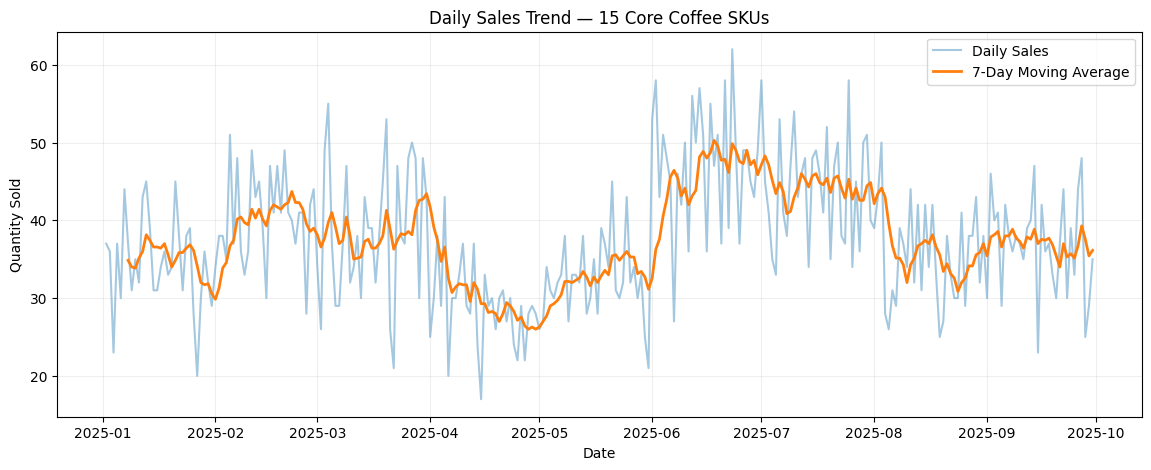

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_total["Date"],
    daily_total["TotalQty"],
    alpha=0.4,
    label="Daily Sales"
)

plt.plot(
    daily_total["Date"],
    daily_total["Rolling7"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.title("Daily Sales Trend — 15 Core Coffee SKUs")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [73]:
# EDA 5 — Lag Correlation

df_lag = forecast_dataset.copy()

df_lag = df_lag.sort_values(
    ["Outlet", "ProductId", "Date"]
)

lags = [1, 2, 3, 7, 14]

for lag in lags:
    df_lag[f"lag_{lag}"] = (
        df_lag
        .groupby(["Outlet", "ProductId"])["QuantitySold"]
        .shift(lag)
    )

lag_correlations = {}

for lag in lags:
    corr = df_lag[
        ["QuantitySold", f"lag_{lag}"]
    ].corr().iloc[0, 1]

    lag_correlations[f"lag_{lag}"] = corr

lag_corr_df = (
    pd.DataFrame(
        lag_correlations.items(),
        columns=["Lag", "Correlation"]
    )
)

display(lag_corr_df)

,Lag,Correlation
0,lag_1,0.114275
1,lag_2,0.097835
2,lag_3,0.101091
3,lag_7,0.091218
4,lag_14,0.079874


In [74]:
series_lag_corr = []

for (outlet, product_id), group in df_lag.groupby(
    ["Outlet", "ProductId"]
):
    row = {
        "Outlet": outlet,
        "ProductId": product_id
    }

    for lag in lags:
        row[f"lag_{lag}"] = (
            group["QuantitySold"]
            .corr(group[f"lag_{lag}"])
        )

    series_lag_corr.append(row)

series_lag_corr = pd.DataFrame(series_lag_corr)

display(series_lag_corr.head())

print("\nMedian correlation across 45 series:")

display(
    series_lag_corr[
        [f"lag_{x}" for x in lags]
    ].median()
)

,Outlet,ProductId,lag_1,lag_2,lag_3,lag_7,lag_14
0,SHOP001,5,-0.009996,-0.002753,0.032671,-0.047286,-0.010837
1,SHOP001,6,0.027493,-0.106504,0.019300,-0.008510,0.040748
2,SHOP001,8,-0.044542,0.010280,0.015443,0.086601,0.109692
3,SHOP001,15,0.123894,0.097982,0.091116,0.057886,-0.065431
4,SHOP001,18,0.040717,-0.038159,0.046675,0.005529,0.103871



Median correlation across 45 series:


lag_1     0.027207
lag_2     0.004149
lag_3     0.019178
lag_7     0.012251
lag_14   -0.010837
dtype: float64

In [75]:
# Rolling statistics
# IMPORTANT: shift(1) prevents target leakage

grouped = df_lag.groupby(
    ["Outlet", "ProductId"]
)["QuantitySold"]

df_lag["rolling_mean_7"] = (
    grouped
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

df_lag["rolling_mean_14"] = (
    grouped
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

df_lag["rolling_sum_7"] = (
    grouped
    .transform(
        lambda x: x.shift(1).rolling(7).sum()
    )
)

print(
    "Rolling Mean 7 correlation:",
    df_lag["QuantitySold"].corr(
        df_lag["rolling_mean_7"]
    )
)

print(
    "Rolling Mean 14 correlation:",
    df_lag["QuantitySold"].corr(
        df_lag["rolling_mean_14"]
    )
)

Rolling Mean 7 correlation: 0.21687617313952837
Rolling Mean 14 correlation: 0.24602684947286985


In [76]:
forecast_dataset.to_csv(
    "../data/processed/forecast_dataset.csv",
    index=False
)